In [3]:
import nocd # Manggil modul nocd
import matplotlib.pyplot as plt # untuk visualisasi
import numpy as np # untuk operasi matriks dan data sparse
import scipy.sparse as sp # untuk operasi matriks dan data sparse
import torch # untuk deep learning
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import normalize # untuk normalisasi matriks input

# untuk magic command, agar plot di chart bisa jadi satu untuk ditampilinnya.
%matplotlib inline 

# Hapus atau komentari baris ini jika tidak ada GPU (CUDA)
# torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Defining and training the model

Load the dataset
 - `A` (adjacency matrix) is a `scipy.sparse.csr_matrix` of size `[N, N]` ~ matriks ketetanggan
 - `X` (attribute matrix) is a `scipy.sparse.csr_matrix` of size `[N, D]` ~ matriks fitur node
 - `Z_gt` (binary community affiliation matrix) is a `np.ndarray` of size `[N, K]` ~ ground thurh, matriks afilasi komunitas sebenarnya

In [4]:
loader = nocd.data.load_dataset('data/mag_chem.npz')
A, X, Z_gt = loader['A'], loader['X'], loader['Z']
N, K = Z_gt.shape

Define the hyperparameters

In [5]:
# Menenutkan ukuran lapisan tersembunyi (hidden layer)
hidden_sizes = [128]    # hidden sizes of the GNN

# Kekuatan L2 Regularization. untuk loss function, mencegah overfitting (membuat bobot model sekecil mungkin)
weight_decay = 1e-2     # strength of L2 regularization on GNN weights

# Memnentukan probabilitas node yang diabaikan (di-drop) secara acak. Teknik regulatizaion untuk mencegah overfitting
dropout = 0.5           # whether to use dropout

# Menggunakan Batch Normalizaion, mempercepat pelatihan dengan menstabilkan ke setiap lapisan
batch_norm = True       # whether to use batch norm

# Learning Rate. menentukan besasar langkah yang diambil optimizer (Adam) saat memperbarui bobot model setelah menghitung loss
lr = 1e-3               # learning rate

# Jumlah maksimum iterasi yang akan dijalankan model
max_epochs = 500        # number of epochs to train

# Seberapa sering metrik (seperti loss dan NMI) dihitung ditampilkan di konsol
display_step = 25       # how often to compute validation loss

# Menentukan apakah loss function disesuaikan untuk mengatasai ketidakseimbangan antara edge yang ada dalam Matriks A
balance_loss = True     # whether to use balanced loss

# Menggunakan stochastic training , metode stochastic (mini-batch) atau full-batch
stochastic_loss = True  # whether to use stochastic or full-batch training

# Jumlah sample edge yang digunakan dalam setiap iterasi pembaruan loss (hanya relevan jika stochastic_loss=True)
batch_size = 20000      # batch size (only for stochastic training)

Select & normalize the feature matrix

For some datasets where the features are very informative / correlated with the community structure it's better to use `X` as input (e.g. co-authorship networks w/ keywords as node features). Otherwise, you should try using `A` or `[A, X]` as input.

=== \
Ini milih Mode intinya, mau fokus ke A, atau X. Atau keduanya. \
Jika X tidak memiliki korelasi, maka pilih yang A. \
Jika X memiliki korelasi, maka pilih yang [A].\
Jika keduanya memiliki korelasi, maka pilih yang [A, X]. (Hasil maksimal harusnya).

In [6]:
### Pilih mode untuk input
# x_norm = normalize(X)  # node features
x_norm = normalize(A)  # adjacency matrix
# x_norm = sp.hstack([normalize(X), normalize(A)])  # concatenate A and X

### Ubah menjadi format sparse tensor di PyTorch
x_norm = nocd.utils.to_sparse_tensor(x_norm)
# x_norm = nocd.utils.to_sparse_tensor(x_norm).cuda()

f:\UPN V YK\$-TA\#Tugas Akhir - Skripsi\Program\dari-journal\overlapping-community-detection\nocd\utils.py:41: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:646.)
  sparse_tensor = torch.sparse.FloatTensor(indices, values, shape)


Define the GNN model

In [7]:
sampler = nocd.sampler.get_edge_sampler(A, batch_size, batch_size, num_workers=5)
# gnn = nocd.nn.GCN(x_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout).cuda()
gnn = nocd.nn.GCN(x_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout)
adj_norm = gnn.normalize_adj(A)
decoder = nocd.nn.BerpoDecoder(N, A.nnz, balance_loss=balance_loss)
opt = torch.optim.Adam(gnn.parameters(), lr=lr)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:624: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
### Fungsi untuk menghitung Overlapping NMI
### Simpelnya untuk evaluasi dari GNN
def get_nmi(thresh=0.5):
    """Compute Overlapping NMI of the communities predicted by the GNN."""
    gnn.eval()
    Z = F.relu(gnn(x_norm, adj_norm))
    Z_pred = Z.cpu().detach().numpy() > thresh
    nmi = nocd.metrics.overlapping_nmi(Z_pred, Z_gt)
    return nmi

Training loop

In [9]:
val_loss = np.inf
validation_fn = lambda: val_loss
early_stopping = nocd.train.NoImprovementStopping(validation_fn, patience=10)
model_saver = nocd.train.ModelSaver(gnn)

for epoch, batch in enumerate(sampler):
    if epoch > max_epochs:
        break
    if epoch % 25 == 0:
        with torch.no_grad():
            gnn.eval()
            # Compute validation loss
            Z = F.relu(gnn(x_norm, adj_norm))
            val_loss = decoder.loss_full(Z, A)
            print(f'Epoch {epoch:4d}, loss.full = {val_loss:.4f}, nmi = {get_nmi():.2f}')
            
            # Check if it's time for early stopping / to save the model
            early_stopping.next_step()
            if early_stopping.should_save():
                model_saver.save()
            if early_stopping.should_stop():
                print(f'Breaking due to early stopping at epoch {epoch}')
                break
            
    # Training step
    gnn.train()
    opt.zero_grad()
    Z = F.relu(gnn(x_norm, adj_norm))
    ones_idx, zeros_idx = batch
    if stochastic_loss:
        loss = decoder.loss_batch(Z, ones_idx, zeros_idx)
    else:
        loss = decoder.loss_full(Z, A)
    loss += nocd.utils.l2_reg_loss(gnn, scale=weight_decay)
    loss.backward()
    opt.step()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:624: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 4 (`cpuset` is not taken into account), which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch    0, loss.full = 0.6217, nmi = 0.00
Epoch   25, loss.full = 0.3044, nmi = 0.08
Epoch   50, loss.full = 0.2495, nmi = 0.13
Epoch   75, loss.full = 0.2371, nmi = 0.17
Epoch  100, loss.full = 0.2182, nmi = 0.20
Epoch  125, loss.full = 0.2149, nmi = 0.20
Epoch  150, loss.full = 0.2168, nmi = 0.21
Epoch  175, loss.full = 0.2151, nmi = 0.21
Epoch  200, loss.full = 0.2179, nmi = 0.18
Epoch  225, loss.full = 0.2118, nmi = 0.17
Epoch  250, loss.full = 0.2098, nmi = 0.19
Epoch  275, loss.full = 0.2082, nmi = 0.19
Epoch  300, loss.full = 0.2040, nmi = 0.22
Epoch  325, loss.full = 0.2107, nmi = 0.20
Epoch  350, loss.full = 0.2064, nmi = 0.19
Epoch  375, loss.full = 0.2060, nmi = 0.21
Epoch  400, loss.full = 0.2074, nmi = 0.20
Epoch  425, loss.full = 0.2090, nmi = 0.22
Epoch  450, loss.full = 0.2090, nmi = 0.20
Epoch  475, loss.full = 0.2046, nmi = 0.23
Epoch  500, loss.full = 0.2096, nmi = 0.23


Depending on whether you use balanced loss or not, you should (probably) use different threshold values. From my experience, following are reasonable defaults:
 - for `balance_loss = True`: `thresh = 0.5`
 - for `balance_loss = False`: `thresh = 0.01`
 
You can look at the distribution of the non-zero entries of `Z` to decide on a good value for the threshold. 
I guess it makes sense to select a value that lies in the leftmost "valley" of histogram below. 
You can also look at the unsupervised metrics in the next section of this notebook to make an informed choice.

Note that all of these are just speculations based on the behavior that I observed for a handful of datasets, YMMV.("your mileage may vary")-(hasil atau pengalaman Anda mungkin berbeda)

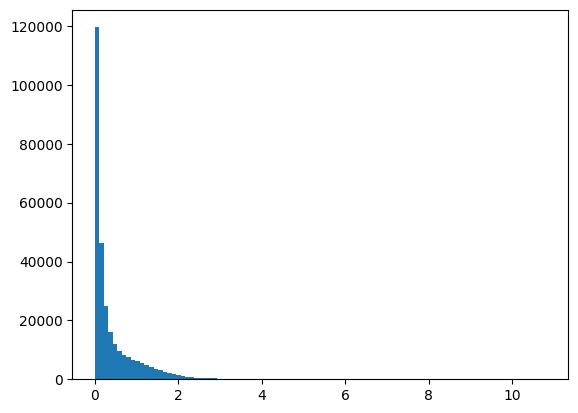

In [10]:
plt.hist(Z[Z > 0].cpu().detach().numpy(), 100);

In [11]:
thresh = 0.5

Z = F.relu(gnn(x_norm, adj_norm))
Z_pred = Z.cpu().detach().numpy() > thresh
model_saver.restore()
print(f'Final nmi = {get_nmi(thresh):.3f}')

Final nmi = 0.217


# Analyzing the results

### Visualize the adjacency matrix sorted by the communities

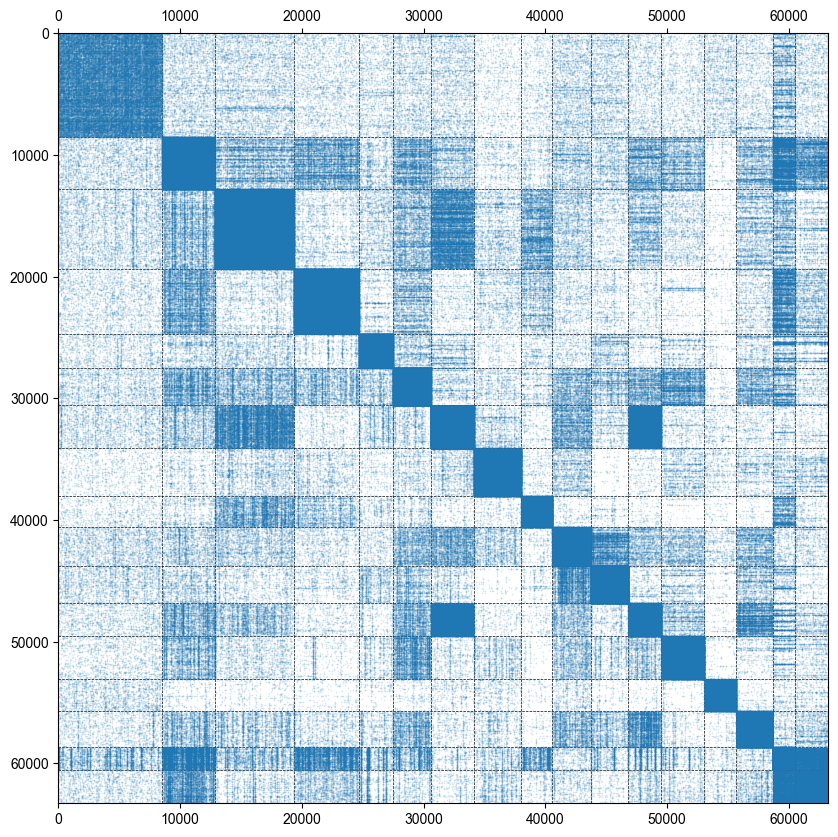

In [12]:
plt.figure(figsize=[10, 10])
z = np.argmax(Z_pred, 1)
o = np.argsort(z)
nocd.utils.plot_sparse_clustered_adjacency(A, K, z, o, markersize=0.05)

In [13]:
# Sizes of detected communities
print(Z_pred.sum(0))

[3180 4337 6871 5739 3081 4014 4583 4674 3769 4714 4119 5355 5131 3316
 5414 3805 4892]


### Iseng nampilin hasil komunitas

In [14]:
# Pastikan menggunakan matriks Z_pred yang terakhir (sudah biner)
# Z_pred adalah [N, K] matriks biner, di mana Z_pred[u, c] = 1 jika node u milik komunitas c.

# Konversi Matriks Komunitas Biner ke List Node
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

print(f"Total Komunitas Terdeteksi (K): {len(communities_list)}")
print("-" * 40)
print("Daftar Node per Komunitas (Matriks ke List):\n")

# Menampilkan hasil (hanya menampilkan 5 komunitas pertama dan yang tidak kosong)
count = 0
for i, community in enumerate(communities_list):
    # Memeriksa apakah komunitas tersebut memiliki anggota
    if len(community) > 0:
        print(f"Komunitas {i} (Jumlah Node: {len(community)}):")
        # Menampilkan node, dibatasi hingga 10 node pertama per komunitas untuk output yang ringkas
        if len(community) > 10:
            print(f"  {community[:10]} ... [Total {len(community)} node]")
        else:
            print(f"  {community}")
        count += 1
        
        if count >= 5 and len(communities_list) > 5:
            print("\n... (Menampilkan hanya 5 komunitas non-kosong pertama)")
            break

if count == 0:
    print("Tidak ada komunitas non-kosong yang terdeteksi berdasarkan ambang batas 0.5.")

Total Komunitas Terdeteksi (K): 17
----------------------------------------
Daftar Node per Komunitas (Matriks ke List):

Komunitas 0 (Jumlah Node: 3180):
  [np.int64(8), np.int64(24), np.int64(124), np.int64(133), np.int64(141), np.int64(164), np.int64(219), np.int64(228), np.int64(257), np.int64(269)] ... [Total 3180 node]
Komunitas 1 (Jumlah Node: 4337):
  [np.int64(12), np.int64(13), np.int64(26), np.int64(56), np.int64(70), np.int64(106), np.int64(149), np.int64(173), np.int64(193), np.int64(230)] ... [Total 4337 node]
Komunitas 2 (Jumlah Node: 6871):
  [np.int64(2), np.int64(12), np.int64(17), np.int64(23), np.int64(30), np.int64(45), np.int64(60), np.int64(104), np.int64(136), np.int64(143)] ... [Total 6871 node]
Komunitas 3 (Jumlah Node: 5739):
  [np.int64(14), np.int64(20), np.int64(31), np.int64(43), np.int64(53), np.int64(61), np.int64(63), np.int64(64), np.int64(65), np.int64(67)] ... [Total 5739 node]
Komunitas 4 (Jumlah Node: 3081):
  [np.int64(48), np.int64(147), np.int6

In [1]:
import numpy as np

# Konversi Matriks Komunitas Biner ke List Indeks Node
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

# FIX: PENTING! Konversi node_names menjadi array NumPy untuk advanced indexing
if not isinstance(node_names, np.ndarray):
    node_names = np.array(node_names)

print(f"Total Komunitas Terdeteksi (K): {len(communities_list)}")
print("-" * 60)
print("Daftar Nama Node per Komunitas:\n")

# Fungsi untuk memetakan indeks ke nama
def map_indices_to_names(index_list, names_array):
    # Baris ini sekarang akan bekerja karena names_array adalah array NumPy
    return names_array[index_list]

count = 0
for i, community_indices in enumerate(communities_list):
    # Hanya memproses komunitas yang memiliki anggota
    if len(community_indices) > 0:
        
        # --- Lakukan Pemetaan dari Indeks ke Nama ---
        community_names = map_indices_to_names(community_indices, node_names)

        print(f"Komunitas {i} (Jumlah Node: {len(community_names)}):")
        
        # Menampilkan output dengan batas 10 nama
        if len(community_names) > 10:
            # Mengonversi 10 nama pertama menjadi list agar mudah dicetak
            first_ten_names = community_names[:10].tolist() 
            print(f"  {first_ten_names} ... [Total {len(community_names)} node]")
        else:
            print(f"  {community_names.tolist()}")
        
        count += 1
        
        if count >= 5 and len(communities_list) > 5:
            print("\n... (Menampilkan hanya 5 komunitas non-kosong pertama)")
            break

if count == 0:
    print("Tidak ada komunitas non-kosong yang terdeteksi.")

NameError: name 'nocd' is not defined

### Quantify quality of the communities based on unsupervised metrics.

Metrics:
* **Coverage**: what percentage of the edges is explained by at least one community? (i.e. if $(u, v)$ is an edge, both nodes share at least one community) Higher is better.
$$\textrm{Coverage}(C_1, ..., C_K) = \frac{1}{|E|}\sum_{u, v \in E} \mathbb{1}[z_u^T z_v > 0]$$


* **Density**: average density of the detected communities (weighted by community size). Higher is better.

$$\rho(C) = \frac{\text{# existing edges in $C$}}{\text{# of possible edges in $C$}}$$

$$\textrm{AvgDensity}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \rho(C_i) \cdot |C_i|$$


* **Conductance**: average conductance of the detected communities (weighted by community size). Lower is better.

$$\textrm{outside}(C) = \sum_{u \in C, v \notin C} A_{uv}$$

$$\textrm{inside}(C) = \sum_{u \in C, v \in C, v \ne u} A_{uv}$$

$$\textrm{Conductance}(C) = \frac{\textrm{outside}(C)}{\textrm{inside}(C) + \textrm{outside}(C)}$$

$$\textrm{AvgConductance}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \textrm{Conductance}(C_i) \cdot |C_i|$$


* **Clustering coefficient**: average clustering coefficient of the detected communities (weighted by community size). Higher is better.

$$\textrm{ClustCoef}(C) = \frac{\text{# existing triangles in $C$}}{\text{# of possible triangles in $C$}}$$

$$\textrm{AvgClustCoef}(C_1, ..., C_K) = \frac{1}{\sum_i |C_i|}\sum_i \textrm{ClustCoef}(C_i) \cdot |C_i|$$

Clustering coefficient & density of the entire graph

In [16]:
density_baseline = A.nnz / (N**2 - N)
num_triangles = (A @ A @ A).diagonal().sum() / 6
num_possible_triangles = (N - 2) * (N - 1) * N / 6
clust_coef_baseline = num_triangles / num_possible_triangles
print(f'Background (over the entire graph):\n'
      f' - density    = {density_baseline:.3e}\n'
      f' - clust_coef = {clust_coef_baseline:.3e}')

Background (over the entire graph):
 - density    = 4.047e-04
 - clust_coef = 1.208e-07


In [17]:
metrics = nocd.metrics.evaluate_unsupervised(Z_gt, A)
print(f"Ground truth communities:\n"
      f" - coverage    = {metrics['coverage']:.4f}\n"
      f" - conductance = {metrics['conductance']:.4f}\n"
      f" - density     = {metrics['density']:.3e}\n"
      f" - clust_coef  = {metrics['clustering_coef']:.3e}")

Ground truth communities:
 - coverage    = 0.9514
 - conductance = 0.3575
 - density     = 3.437e-03
 - clust_coef  = 1.219e-05


In [ ]:
metrics = nocd.metrics.evaluate_unsupervised(Z_pred, A)
print(f"Predicted communities:\n"
      f" - coverage    = {metrics['coverage']:.4f}\n"
      f" - conductance = {metrics['conductance']:.4f}\n"
      f" - density     = {metrics['density']:.3e}\n"
      f" - clust_coef  = {metrics['clustering_coef']:.3e}")

Predicted communities:
 - coverage    = 0.9241
 - conductance = 0.2151
 - density     = 2.529e-03
 - clust_coef  = 4.630e-06


The detected partition has lower conductance / higher density / higher clustering coefficient than the GT communities.

Tambahan Sendiri

In [ ]:
# Contoh Penggunaan (Simulasi data)
# N=4 nodes, C=2 communities
# Jaringan (0-1, 1-2, 2-3)
adj = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0]
])

# Komunitas 1: {0, 1, 2}, Komunitas 2: {1, 2, 3} (Tumpang tindih di 1 dan 2)
memb_matrix = np.array([
    [1, 0], # Node 0
    [1, 1], # Node 1 (Overlapping)
    [1, 1], # Node 2 (Overlapping)
    [0, 1]  # Node 3
])

# Link Membership untuk Link Modularity (asumsi Link (1,2) milik dua komunitas)
link_memb = {
    (0, 1): [0],
    (1, 2): [0, 1], # Tumpang tindih link
    (2, 3): [1]
}

# Link Modularity menggunakan indeks yang sesuai dengan adj_matrix
link_memb_adj = {}
for (i, j), comms in link_memb.items():
    # Pastikan urutan tuple sesuai (i < j) untuk konsistensi
    if i < j:
        link_memb_adj[(i, j)] = comms
    else:
        link_memb_adj[(j, i)] = comms


metrics = nocd.metrics.evaluate_modularity(adj, memb_matrix, link_memb_adj)
print(f"Contoh (Overlapping Modularity): {metrics['overlapping_modularity']:.4f}")
print(f"Contoh (Link Modularity): {metrics['link_modulrity']:.4f}\n")



Contoh Q_ov (Overlapping Modularity): 0.1667
Contoh Q_L (Link Modularity): 0.5556



Note : 
- Overllaping Modularity = Semakin mendekati 1, semakin bagus, tandanya yang ditemukan bagus
- Link Modularity = Semakin mendekati 1, semakin bagus, tandanya yang ditemukan bagus


In [20]:
# Coba save model

import torch

# 1. Pulihkan bobot model terbaik yang telah disimpan selama proses training
# Ini akan memuat bobot terbaik ke objek 'gnn' Anda.
model_saver.restore()

# 2. Definisikan nama file untuk menyimpan bobot
FILE_NAME = 'export/model_nocd_test1.pth' 

# 3. Simpan hanya state dictionary (bobot) dari model GNN
# torch.save() adalah fungsi standar untuk menyimpan objek Python,
# di mana 'gnn.state_dict()' adalah objek bobot model.
torch.save(gnn.state_dict(), FILE_NAME)

print(f"Model berhasil diexport ke: {FILE_NAME}")

Model berhasil diexport ke: export/model_nocd_test1.pth


In [31]:
# Coba pakai model export

import torch
import nocd
# ... dan definisikan ulang semua parameter model (hidden_sizes, K, dll.)

# 1. Definisikan ulang model dengan arsitektur yang SAMA
# Contoh:
K = 17 
# hidden_sizes = [128]
# D_in = x_norm.shape[1] # Dimensi input yang sama
gnn_loaded = nocd.nn.GCN(x_norm.shape[1], hidden_sizes, K) 
gnn_loaded.load_state_dict(torch.load("export/model_nocd_test1.pth"))

# 2. Set model ke mode evaluasi
gnn_loaded.eval()

# ----

# 2. Lakukan perhitungan tanpa melacak gradien
with torch.no_grad():
    # Z adalah matriks keanggotaan mentah (floating point)
    # F.relu digunakan sesuai arsitektur NOCD
    Z = F.relu(gnn_loaded(x_norm, adj_norm)) 

# 3. Binerisasi untuk mendapatkan Matriks Keanggotaan Akhir
# Gunakan threshold (misal 0.5) yang sama seperti saat evaluasi model.
thresh = 0.5
Z_pred = Z.cpu().detach().numpy() > thresh

# Z_pred sekarang adalah Matriks Biner N x K (N=Jumlah Node, K=Jumlah Komunitas)

# ---
# Ekstraksi keanggotaan komunitas
# (Memerlukan fungsi utilitas yang Anda gunakan di notebook)
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

# Tampilkan atau Konversi ke JSON (untuk FE)
print(f"Total komunitas terdeteksi (aktif): {len(communities_list)}")

# Contoh konversi untuk FE:
hasil_json = []
for i, community_indices in enumerate(communities_list):
    if len(community_indices) > 0:
        # Menambahkan ID komunitas dan daftar node anggotanya
        hasil_json.append({
            "community_id": i,
            "node_count": len(community_indices),
            "node_indices": community_indices.tolist() # Kirim indeks atau namanya
        })

# Kirim hasil_json ke Front End

Total komunitas terdeteksi (aktif): 17
